In [24]:
# Installs comment out as needed
# !pip install pretty_midi numpy scikit-learn matplotlib pandas
# !python.exe -m pip install --upgrade pip

### How the Similarity Score is Calculated

The similarity score in this workflow is **not using embeddings**, it is a **direct feature-based comparison** between the reference MIDI and an input MIDI. Here's how it works step by step:

1. **Extract Features for Each Note**  
   Each note is represented as a 4-element feature vector:  
   - `pitch` – MIDI note number  
   - `duration` – length of the note in seconds  
   - `tempo` – estimated tempo of the MIDI  
   - `scale` – major (1) or minor (0)

2. **Chunk the Notes**  
   Notes are grouped in two ways:  
   - **Time-based chunks:** consecutive notes within a fixed time window (e.g., 2 seconds)  
   - **Note-count chunks:** consecutive notes in groups of fixed size (e.g., 5 notes)

3. **Compare Chunks Between Reference and Input**  
   For each chunk, the reference and input are aligned. For each feature in the chunk (pitch, duration, tempo, scale), a **normalized difference score** is calculated:  
   \[
   \text{feature similarity} = 1 - \frac{|a - b|}{\max(|a|, |b|)}
   \]  
   - This produces a score between 0 and 1  
   - 1 = identical feature values, 0 = completely different

4. **Aggregate Features per Chunk**  
   The similarity scores of the four features for a chunk are averaged to get a **chunk-level overall similarity**.

5. **Aggregate Across All Chunks**  
   Finally, the chunk-level overall similarities are averaged to get the **final overall similarity score** for the entire MIDI.  

**Summary:**  
> Overall similarity = mean of (pitch, duration, tempo, scale) per chunk → mean across all chunks  

This gives a single numeric score representing how closely the input MIDI matches the reference MIDI.

In [26]:
##########################
# Section 1 - Loading MIDI for comparison
##########################

# Reference MIDI (true Fur Elise)
ref_midi_path = "MidiDatasets/590-Classical-music-midi/beeth/elise.mid"

# Input MIDIs to compare
input_midi_paths = [
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Amin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Bmin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_2ndVerse_K-Gmin_T-75_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_4thVerse_K-Amin_T-79_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_4thVerse_K-Gmin_T-63_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro-2ndVers_K-Amin_T-70_bothhands.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Amaj_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Amin_T-138_righthand_swing.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Amin_T-60_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Cmaj_T-70_righthand.mid",
    "MidiDatasets/TestingSamples/MidiOutputs/FurElise_Intro_K-Cmin_T-60_righthand.mid",
]

# Encode scale: major=1, minor=0
def scale_to_num(scale_str):
    return 1 if "maj" in scale_str.lower() else 0

def extract_note_features(midi_path, scale_num=0):
    midi = pretty_midi.PrettyMIDI(midi_path)
    tempo = midi.estimate_tempo()
    notes = []
    for inst in midi.instruments:
        for n in inst.notes:
            duration = n.end - n.start
            feature = [n.pitch, duration, tempo, scale_num]
            notes.append((n.start, feature))
    notes.sort(key=lambda x: x[0])
    return [f[1] for f in notes]


##########################
# Section 2 - Chunking and similarity calculations
##########################

def chunk_by_note_count(features, chunk_size=5):
    chunks = []
    for i in range(0, len(features), chunk_size):
        chunk = features[i:i+chunk_size]
        if len(chunk) == chunk_size:
            chunks.append(np.array(chunk))
    return chunks

def chunk_by_time(features, window=2.0):
    chunks = []
    current = []
    start_time = 0
    for i, feat in enumerate(features):
        note_start = i  # approximate sequential index for simplicity
        if note_start - start_time <= window:
            current.append(feat)
        else:
            chunks.append(np.array(current))
            current = [feat]
            start_time = note_start
    if current:
        chunks.append(np.array(current))
    return chunks

# Cosine similarity per feature
def compute_feature_similarity(ref_chunks, input_chunks):
    pitch_sims, duration_sims, tempo_sims, scale_sims = [], [], [], []
    min_len = min(len(ref_chunks), len(input_chunks))
    
    for i in range(min_len):
        ref = ref_chunks[i]
        inp = input_chunks[i]
        
        # Using normalized absolute difference instead of cosine similarity
        # 1.0 = identical, 0.0 = completely different
        def calc_score(a, b):
            min_len = min(len(a), len(b))
            a, b = a[:min_len], b[:min_len]
            diff = np.abs(a - b)
            denom = np.maximum(np.abs(a), np.abs(b))
            denom[denom == 0] = 1  # avoid div by zero
            return np.mean(1 - (diff / denom))

        pitch_sims.append(calc_score(ref[:, 0], inp[:, 0]))
        duration_sims.append(calc_score(ref[:, 1], inp[:, 1]))
        tempo_sims.append(calc_score(ref[:, 2], inp[:, 2]))
        scale_sims.append(calc_score(ref[:, 3], inp[:, 3]))
        
    overall_sims = np.mean([pitch_sims, duration_sims, tempo_sims, scale_sims], axis=0)
    return pitch_sims, duration_sims, tempo_sims, scale_sims, overall_sims


##########################
# Section 3 - Compute similarities and prepare for plotting
##########################

results = []

for path in input_midi_paths:
    scale_num = 1 if "_maj_" in path.lower() else 0
    ref_features = extract_note_features(ref_midi_path, scale_num)
    input_features = extract_note_features(path, scale_num)
    
    # Chunk by time
    ref_time_chunks = chunk_by_time(ref_features, 2.0)
    input_time_chunks = chunk_by_time(input_features, 2.0)
    pitch_t, dur_t, tempo_t, scale_t, overall_t = compute_feature_similarity(ref_time_chunks, input_time_chunks)
    
    # Chunk by note count
    ref_note_chunks = chunk_by_note_count(ref_features, 5)
    input_note_chunks = chunk_by_note_count(input_features, 5)
    pitch_n, dur_n, tempo_n, scale_n, overall_n = compute_feature_similarity(ref_note_chunks, input_note_chunks)
    
    results.append({
        "file": path.split("/")[-1],
        "time_pitch": np.mean(pitch_t),
        "time_duration": np.mean(dur_t),
        "time_tempo": np.mean(tempo_t),
        "time_scale": np.mean(scale_t),
        "time_overall": np.mean(overall_t),
        "note_pitch": np.mean(pitch_n),
        "note_duration": np.mean(dur_n),
        "note_tempo": np.mean(tempo_n),
        "note_scale": np.mean(scale_n),
        "note_overall": np.mean(overall_n)
    })

df = pd.DataFrame(results)

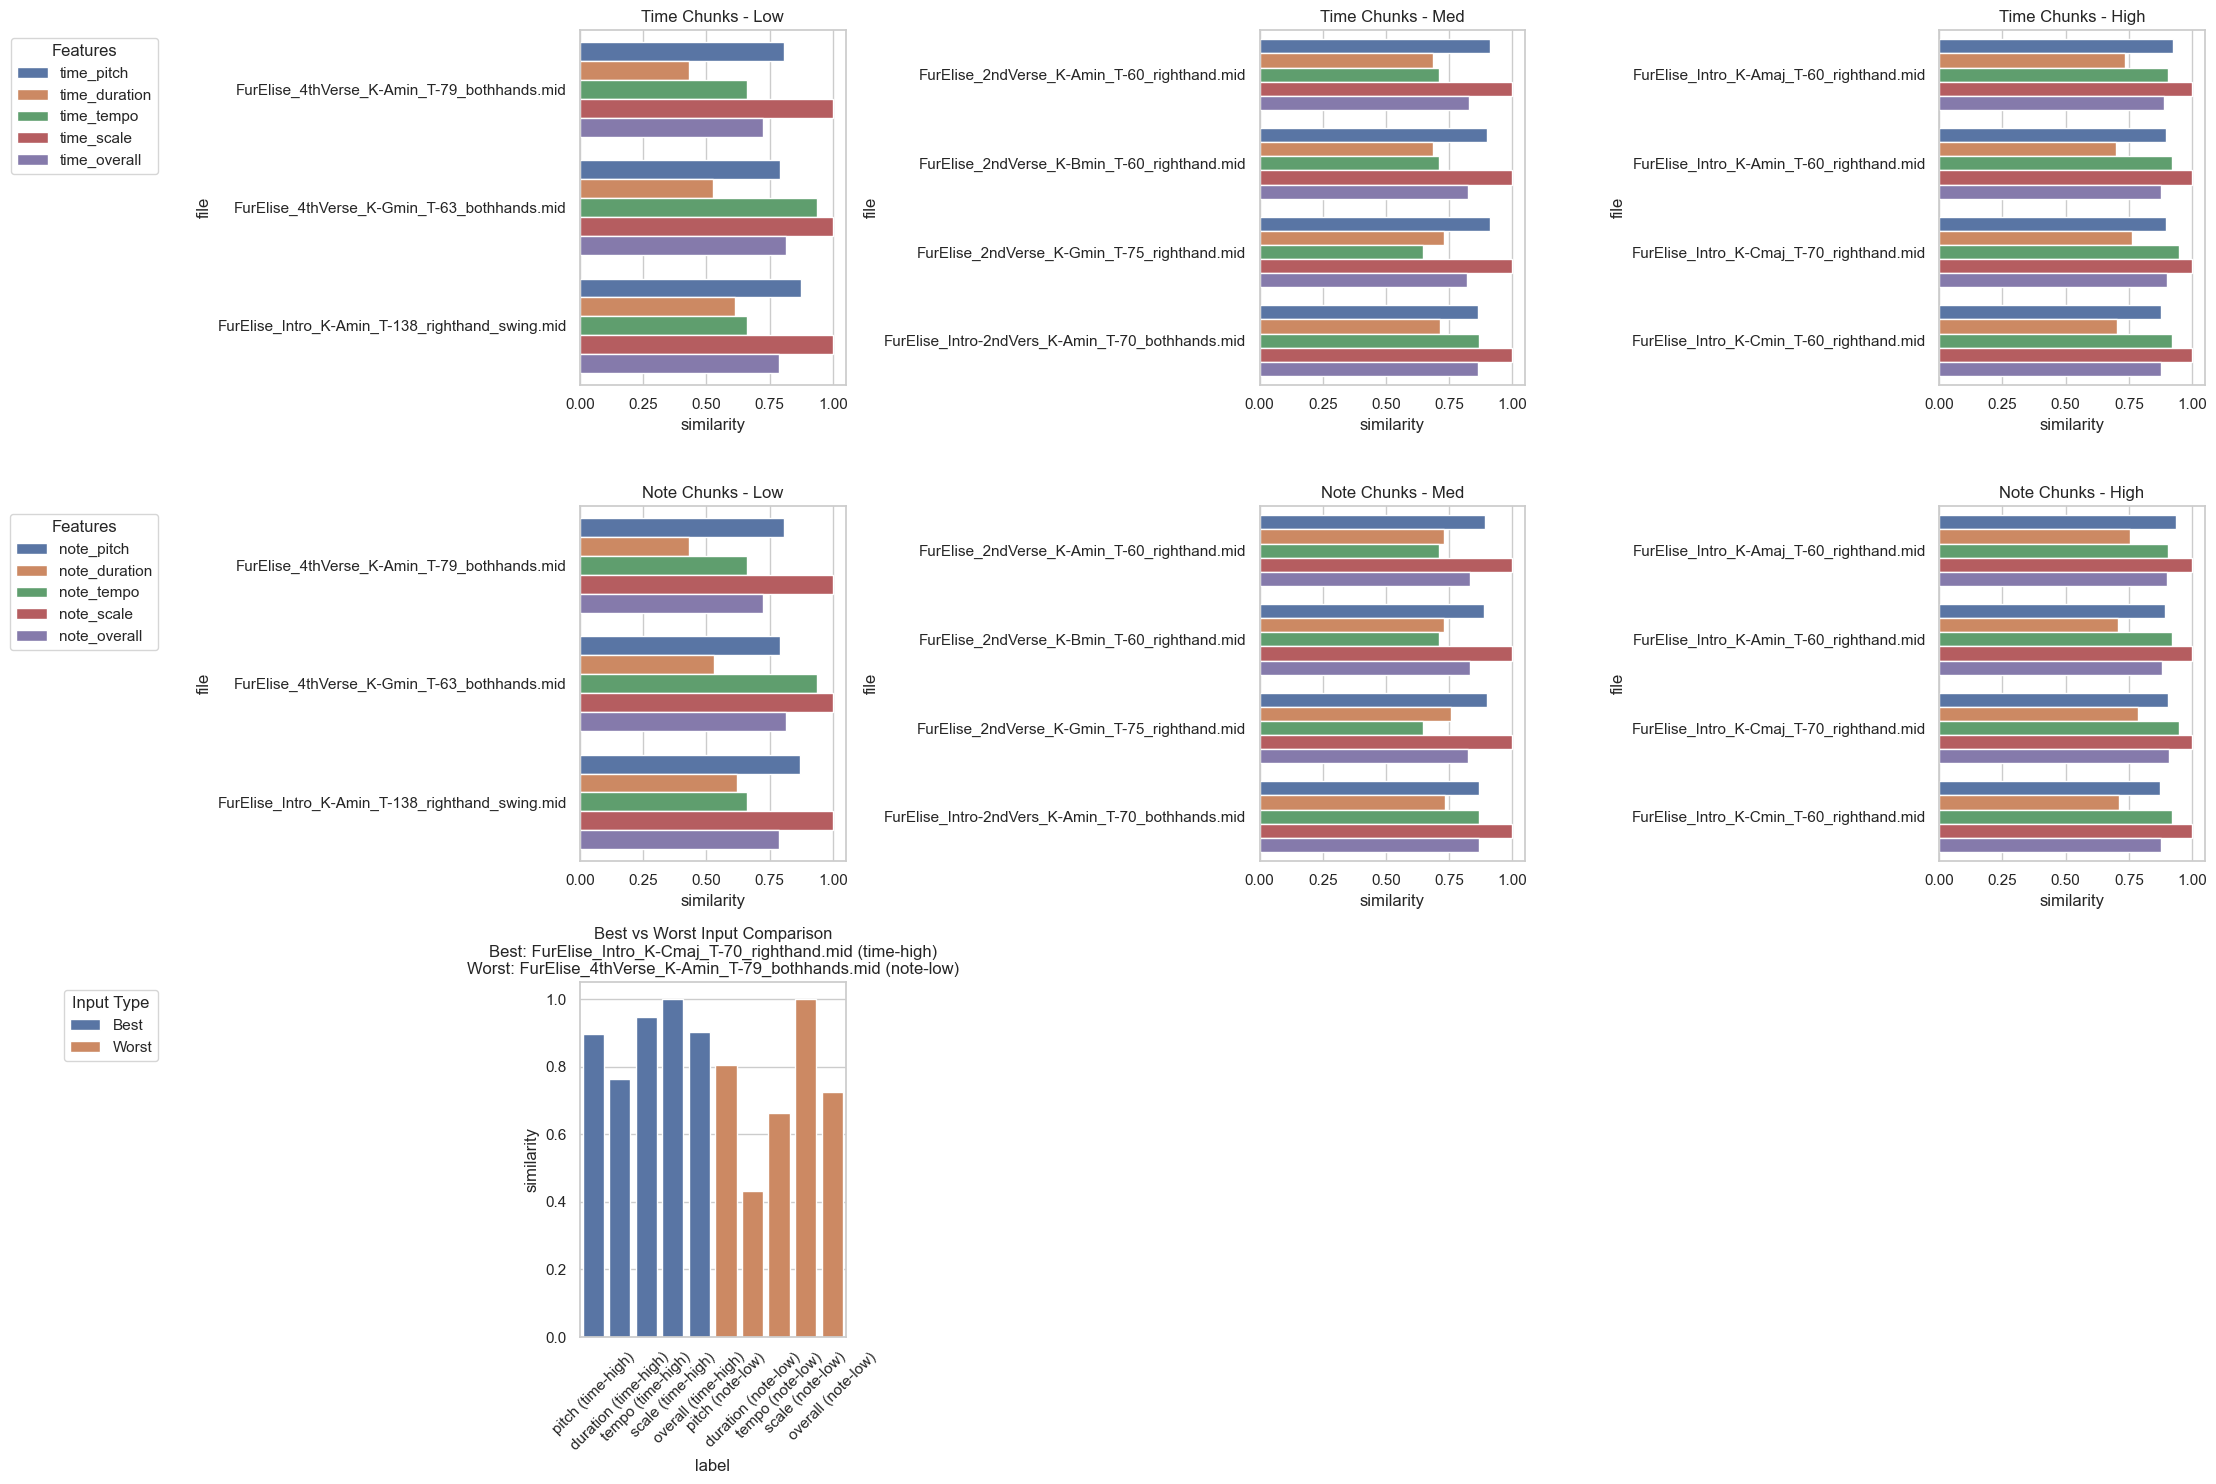

In [27]:
##########################
# Section 4 - Combined plotting with legends only in first column
##########################

sns.set(style="whitegrid")

# Melt for Seaborn
df_time = df.melt(
    id_vars="file",
    value_vars=["time_pitch","time_duration","time_tempo","time_scale","time_overall"],
    var_name="feature",
    value_name="similarity"
)
df_note = df.melt(
    id_vars="file",
    value_vars=["note_pitch","note_duration","note_tempo","note_scale","note_overall"],
    var_name="feature",
    value_name="similarity"
)

fig, axes = plt.subplots(3, 4, figsize=(22, 15), gridspec_kw={'width_ratios':[0.15,1,1,1]})

# Hide first column axes for legend placeholders
for row in range(3):
    axes[row,0].axis('off')

# Helper: split files by low/med/high based on overall
def get_split_files(df, col, split):
    sorted_files = df.sort_values(col)["file"].values
    n = len(sorted_files)
    if split == "low":
        return sorted_files[:n//3]
    elif split == "med":
        return sorted_files[n//3:2*n//3]
    elif split == "high":
        return sorted_files[2*n//3:]
    else:
        return sorted_files

# --- Row 1: Time chunks ---
for i, split in enumerate(["low", "med", "high"]):
    sns.barplot(
        x="similarity", y="file", hue="feature",
        data=df_time[df_time["file"].isin(get_split_files(df, "time_overall", split))],
        ax=axes[0,i+1]
    )
    axes[0,i+1].set_title(f"Time Chunks - {split.capitalize()}")
    axes[0,i+1].legend_.remove()  # remove individual legend

# Assign legend to first column
handles, labels = axes[0,1].get_legend_handles_labels()
axes[0,0].legend(handles, labels, title="Features")
axes[0,0].axis('off')

# --- Row 2: Note chunks ---
for i, split in enumerate(["low", "med", "high"]):
    sns.barplot(
        x="similarity", y="file", hue="feature",
        data=df_note[df_note["file"].isin(get_split_files(df, "note_overall", split))],
        ax=axes[1,i+1]
    )
    axes[1,i+1].set_title(f"Note Chunks - {split.capitalize()}")
    axes[1,i+1].legend_.remove()  # remove individual legend

# Assign legend to first column
handles, labels = axes[1,1].get_legend_handles_labels()
axes[1,0].legend(handles, labels, title="Features")
axes[1,0].axis('off')

# --- Row 3: Best vs Worst Input Comparison ---
axes[2,2].axis('off')
axes[2,3].axis('off')

if not df.empty:
    df["overall_avg"] = df[["time_overall","note_overall"]].mean(axis=1)
    best_row = df.loc[df["overall_avg"].idxmax()]
    worst_row = df.loc[df["overall_avg"].idxmin()]

    def get_split_label(row, chunk_type):
        if chunk_type == "time":
            if row["file"] in get_split_files(df, "time_overall", "low"): return "low"
            elif row["file"] in get_split_files(df, "time_overall", "med"): return "med"
            else: return "high"
        else:
            if row["file"] in get_split_files(df, "note_overall", "low"): return "low"
            elif row["file"] in get_split_files(df, "note_overall", "med"): return "med"
            else: return "high"

    best_worst_df = pd.DataFrame([
        {"feature":"pitch", "similarity":best_row["time_pitch"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"duration", "similarity":best_row["time_duration"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"tempo", "similarity":best_row["time_tempo"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"scale", "similarity":best_row["time_scale"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"overall", "similarity":best_row["time_overall"], "input_type":"Best", "chunk":"time", "split":get_split_label(best_row,"time")},
        {"feature":"pitch", "similarity":worst_row["note_pitch"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
        {"feature":"duration", "similarity":worst_row["note_duration"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
        {"feature":"tempo", "similarity":worst_row["note_tempo"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
        {"feature":"scale", "similarity":worst_row["note_scale"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
        {"feature":"overall", "similarity":worst_row["note_overall"], "input_type":"Worst", "chunk":"note", "split":get_split_label(worst_row,"note")},
    ])

    best_worst_df["label"] = best_worst_df["feature"] + " (" + best_worst_df["chunk"] + "-" + best_worst_df["split"] + ")"

    sns.barplot(
        x="label", y="similarity",
        hue="input_type", data=best_worst_df, ax=axes[2,1]
    )
    axes[2,1].set_title(
        f"Best vs Worst Input Comparison\nBest: {best_row['file']} ({best_worst_df[best_worst_df['input_type']=='Best']['chunk'].iloc[0]}-{best_worst_df[best_worst_df['input_type']=='Best']['split'].iloc[0]})\n"
        f"Worst: {worst_row['file']} ({best_worst_df[best_worst_df['input_type']=='Worst']['chunk'].iloc[0]}-{best_worst_df[best_worst_df['input_type']=='Worst']['split'].iloc[0]})"
    )
    axes[2,1].tick_params(axis='x', rotation=45)

    # Assign legend only in first column
    handles, labels = axes[2,1].get_legend_handles_labels()
    axes[2,0].legend(handles, labels, title="Input Type")
    axes[2,0].axis('off')

    # Remove duplicate legend in plot
    axes[2,1].legend_.remove()
else:
    axes[2,1].text(0.5, 0.5, "No valid MIDI comparisons", ha='center', va='center')
    axes[2,1].axis('off')
    axes[2,0].axis('off')

plt.tight_layout()
plt.show()